In [1]:
# import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import scale
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

import warnings  # supress warnings

warnings.filterwarnings("ignore")

In [2]:
housing = pd.read_csv("Housing.csv")

In [3]:
housing.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
sklearn.set_config(enable_metadata_routing=True)

In [5]:
housing.shape

(545, 13)

In [6]:
df = housing[["area", "price"]]
df.head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [7]:
df.corr()

,area,price
area,1.000000,0.535997
price,0.535997,1.000000


<Axes: >

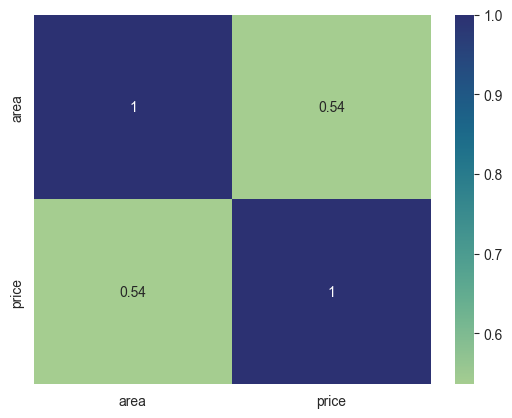

In [8]:
sns.heatmap(df.corr(), annot=True, cmap="crest")

In [9]:
# rescaling the variables (both)
df_columns = df.columns
scaler = MinMaxScaler()
df = scaler.fit_transform(df)

In [10]:
df.dtype

dtype('float64')

In [11]:
type(df)

numpy.ndarray

In [12]:
df_columns

Index(['area', 'price'], dtype='object')

In [13]:
df = pd.DataFrame(df, columns=df_columns)

In [14]:
df

,area,price
0,0.396564,1.000000
1,0.502405,0.909091
2,0.571134,0.909091
3,0.402062,0.906061
4,0.396564,0.836364
...,...,...
540,0.092784,0.006061
541,0.051546,0.001485
542,0.135395,0.000000
543,0.086598,0.000000


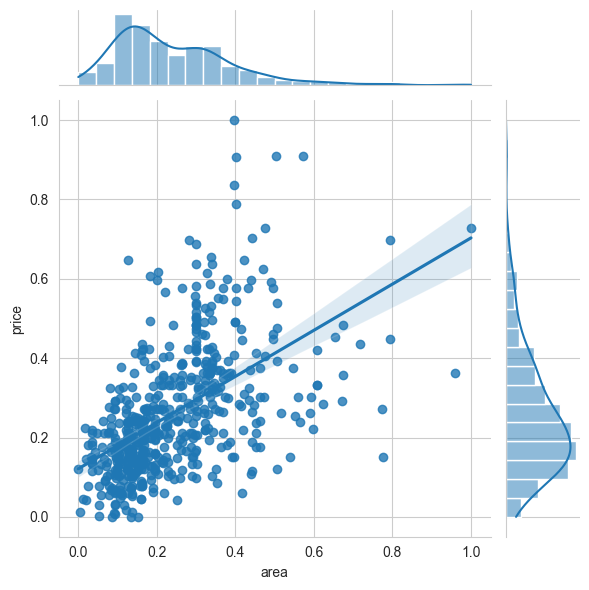

In [15]:
sns.jointplot(df, x="area", y="price", kind="reg")
plt.show()

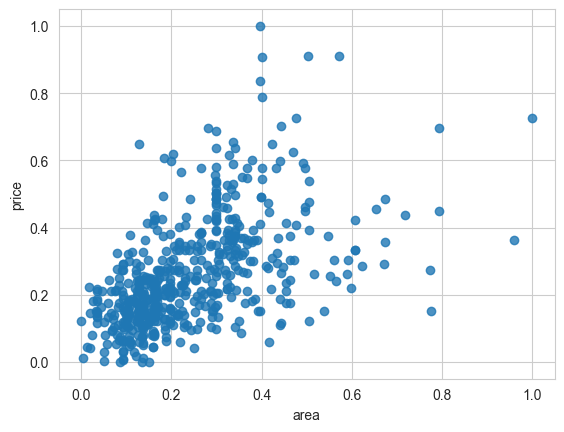

In [16]:
sns.regplot(x="area", y="price", data=df, fit_reg=False)
plt.show()

In [17]:
df_train, df_test = train_test_split(df, train_size=0.7, test_size=0.3, random_state=10)
print(len(df_train))
print(len(df_test))

381
164


In [18]:
X_train, y_train, X_test, y_test = (
    df_train["area"],
    df_train["price"],
    df_test["area"],
    df_test["price"],
)

In [19]:
X_train.values.reshape(-1, 1)

array([[0.56013746],
       [0.33608247],
       [0.12852234],
       [0.45360825],
       [0.10515464],
       [0.16151203],
       [0.27972509],
       [0.12371134],
       [0.27147766],
       [0.51656357],
       [0.29896907],
       [0.15876289],
       [0.00343643],
       [0.06597938],
       [0.10103093],
       [0.37869416],
       [0.29793814],
       [0.67285223],
       [0.25085911],
       [0.50515464],
       [0.79381443],
       [0.1257732 ],
       [0.33676976],
       [0.32646048],
       [0.21649485],
       [0.29621993],
       [0.14776632],
       [0.20274914],
       [0.14501718],
       [0.18694158],
       [0.18969072],
       [0.14776632],
       [0.34020619],
       [0.26460481],
       [0.15697595],
       [0.13402062],
       [0.12783505],
       [0.10549828],
       [0.25773196],
       [0.32783505],
       [0.09278351],
       [0.26460481],
       [0.13608247],
       [0.16426117],
       [0.2233677 ],
       [0.54776632],
       [0.47216495],
       [0.303

### Polynomial Regression

You already know simple linear regression:

$y = \beta_0 + \beta_1 x_1$

In polynomial regression of degree $n$, we fit a curve of the form:

$y = \beta_0 + \beta_1 x_1 + \beta_2x_1^2 + \beta_3x_1^3 ... + \beta_nx_1^n$

In the experiment below, we have fitted polynomials of various degrees on the housing data and compared their performance on train and test sets.

In sklearn, polynomial features can be generated using the `PolynomialFeatures` class. Also, to perform `LinearRegression` and `PolynomialFeatures` in tandem, we will use the module `sklearn_pipeline` - it basically creates the features and feeds the output to the model (in that sequence).

In [20]:
X_train_scaler = X_train.values.reshape(-1, 1)
X_test_scaler = X_test.values.reshape(-1, 1)

NameError: name 'model1' is not defined

{'degree': 3, 'include_bias': True, 'interaction_only': False, 'order': 'C'}

In [22]:
np.zeros([10, 10])

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [23]:
# fit multiple polynomial features
degrees = [1, 2, 3, 6, 10, 20]

# initialise y_train_pred and y_test_pred matrices to store the train and test predictions
# each row is a data point, each column a prediction using a polynomial of some degree
y_train_pred = np.zeros((len(X_train), len(degrees)))
y_test_pred = np.zeros((len(X_test), len(degrees)))

for i, degree in enumerate(degrees):
    # make pipeline: create features, then feed them to linear_reg model
    model = make_pipeline(
        PolynomialFeatures(degree), LinearRegression()
    )  # PolynomialFeatures not Polynomial regression
    model.fit(X_train_scaler, y_train)

    # predict on test and train data
    # store the predictions of each degree in the corresponding column
    y_train_pred[:, i] = model.predict(X_train_scaler)
    y_test_pred[:, i] = model.predict(X_test_scaler)

In [24]:
y_train_pred

array([[0.47418668, 0.43875135, 0.43958014, 0.37283895, 0.35360483,
        0.40341811],
       [0.32965085, 0.36022771, 0.36020318, 0.38693157, 0.39702723,
        0.39449062],
       [0.19575571, 0.18472264, 0.18464659, 0.16859314, 0.16660568,
        0.16024367],
       ...,
       [0.12109364, 0.04393656, 0.04505784, 0.11581114, 0.08645543,
        0.11142059],
       [0.7313363 , 0.2937324 , 0.28889587, 0.35545707, 0.36292343,
        0.36302935],
       [0.16738057, 0.13483757, 0.13507759, 0.13787842, 0.13425014,
        0.14219368]])

In [25]:
from sklearn import metrics

for i, degree in enumerate(degrees):
    print(
        f" R2 score for degree {i + 1}, Train data:{metrics.r2_score(y_train, y_train_pred[:, i])}, Test data:{metrics.r2_score(y_test, y_test_pred[:, i])}"
    )

 R2 score for degree 1, Train data:0.2926639675302787, Test data:0.24837475671431686
 R2 score for degree 2, Train data:0.344445381408635, Test data:0.22489109707448995
 R2 score for degree 3, Train data:0.3444514312104697, Test data:0.2234673614889826
 R2 score for degree 4, Train data:0.36488070883324886, Test data:0.11488156619088874
 R2 score for degree 5, Train data:0.3724494001439942, Test data:-108.7640516729491
 R2 score for degree 6, Train data:0.37629722715059233, Test data:-5612027709.785228


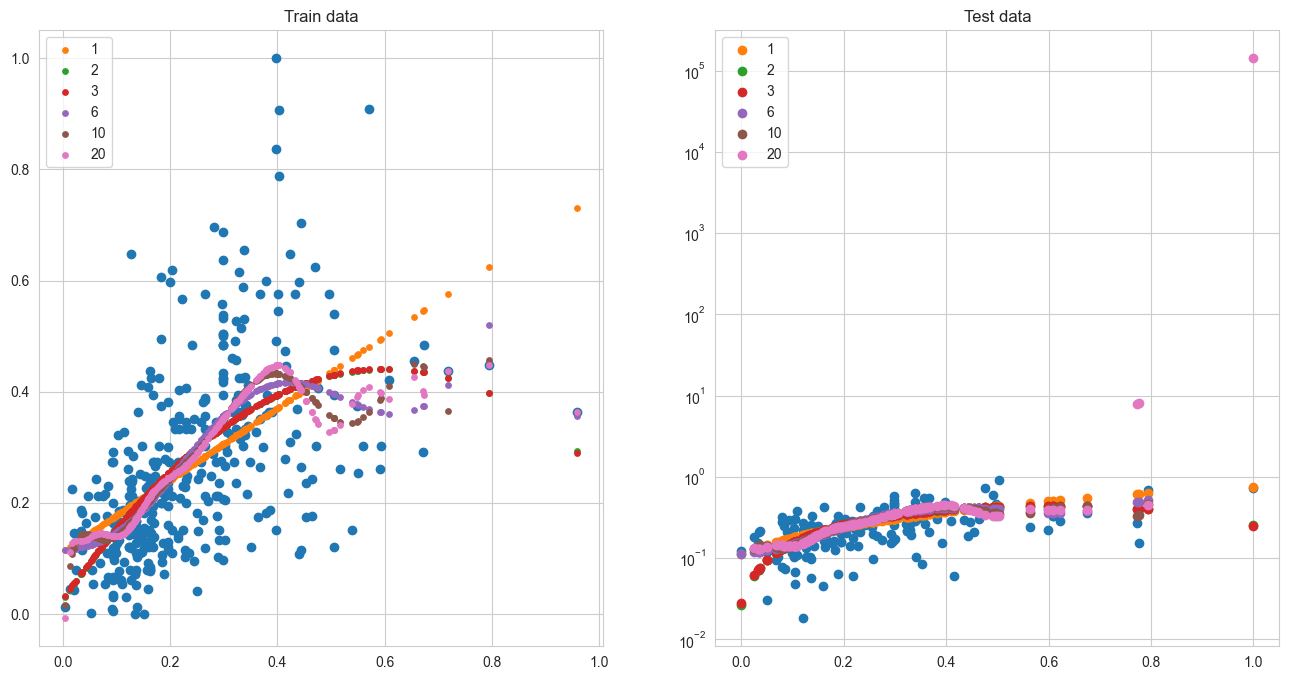

In [26]:
plt.figure(figsize=(16, 8))

# train data
plt.subplot(121)
plt.scatter(X_train_scaler, y_train)
# plt.yscale("log")
# plt.xscale("log")
plt.title("Train data")
for i, degree in enumerate(degrees):
    plt.scatter(X_train_scaler, y_train_pred[:, i], s=15, label=str(degree))
    plt.legend(loc="upper left")

# test data
plt.subplot(122)
plt.scatter(X_test_scaler, y_test)
plt.yscale("log")
plt.title("Test data")
for i, degree in enumerate(degrees):
    plt.scatter(X_test_scaler, y_test_pred[:, i], label=str(degree))
    plt.legend(loc="upper left")

In [27]:
max(X_train_scaler)

array([0.95876289])

### Apparently I am guessing an AI can do all this
#### Either I learn MLOps and GENAI faster... or else revise and look for Java jobs also

In [28]:
# data preparation

# list of all the "yes-no" binary categorical variables
# we'll map yes to 1 and no to 0
binary_vars_list = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
]


# defining the map function
def binary_map(x):
    return x.map({"yes": 1, "no": 0})


# applying the function to the housing variables list
housing[binary_vars_list] = housing[binary_vars_list].apply(binary_map)
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [29]:
# 'dummy' variables
# get dummy variables for 'furnishingstatus'
# also, drop the first column of the resulting df (since n-1 dummy vars suffice)
status = pd.get_dummies(housing["furnishingstatus"], drop_first=True)
status.head()

,semi-furnished,unfurnished
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False


In [30]:
# concat the dummy variable df with the main df
housing = pd.concat([housing, status], axis=1)
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,False,False


In [31]:
# 'furnishingstatus' since we alreday have the dummy vars
housing.drop(["furnishingstatus"], axis=1, inplace=True)
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [32]:
# train-test 70-30 split
df_train, df_test = train_test_split(
    housing, train_size=0.7, test_size=0.3, random_state=100
)

# rescale the features
scaler = MinMaxScaler()

# apply scaler() to all the numeric columns
numeric_vars = ["area", "bedrooms", "bathrooms", "stories", "parking", "price"]
df_train[numeric_vars] = scaler.fit_transform(df_train[numeric_vars])
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
359,0.169697,0.155227,0.4,0.0,0.000000,1,0,0,0,0,0.333333,0,False,True
19,0.615152,0.403379,0.4,0.5,0.333333,1,0,0,0,1,0.333333,1,True,False
159,0.321212,0.115628,0.4,0.5,0.000000,1,1,1,0,1,0.000000,0,False,False
35,0.548133,0.454417,0.4,0.5,1.000000,1,0,0,0,1,0.666667,0,False,False
28,0.575758,0.538015,0.8,0.5,0.333333,1,0,1,1,0,0.666667,0,False,True


In [33]:
# apply rescaling to the test set also
df_test[numeric_vars] = scaler.transform(df_test[numeric_vars])
df_test.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
265,0.229697,0.091869,0.4,0.0,0.333333,1,0,0,0,0,0.000000,1,True,False
54,0.484848,0.366420,0.4,0.5,0.333333,1,1,0,0,1,0.333333,0,True,False
171,0.303030,0.742080,0.4,0.0,0.000000,1,0,0,0,0,0.333333,1,True,False
244,0.242424,0.306582,0.4,0.0,0.333333,1,1,1,0,0,0.000000,1,True,False
268,0.227879,0.274023,0.6,0.0,0.333333,1,0,0,0,1,0.000000,0,True,False


In [34]:
# divide into X_train, y_train, X_test, y_test
y_train = df_train.pop("price")
X_train = df_train

y_test = df_test.pop("price")
X_test = df_test

In [35]:
# first model with an arbitrary choice of n_features
# running RFE with number of features=10

lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=10)
rfe = rfe.fit(X_train, y_train)

In [36]:
# tuples of (feature name, whether selected, ranking)
# note that the 'rank' is > 1 for non-selected features
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('area', np.True_, np.int64(1)),
 ('bedrooms', np.True_, np.int64(1)),
 ('bathrooms', np.True_, np.int64(1)),
 ('stories', np.True_, np.int64(1)),
 ('mainroad', np.True_, np.int64(1)),
 ('guestroom', np.True_, np.int64(1)),
 ('basement', np.False_, np.int64(3)),
 ('hotwaterheating', np.True_, np.int64(1)),
 ('airconditioning', np.True_, np.int64(1)),
 ('parking', np.True_, np.int64(1)),
 ('prefarea', np.True_, np.int64(1)),
 ('semi-furnished', np.False_, np.int64(4)),
 ('unfurnished', np.False_, np.int64(2))]

In [37]:
# predict prices of X_test
y_pred = rfe.predict(X_test)

# evaluate the model on test set
r2 = sklearn.metrics.r2_score(y_test, y_pred)
print(r2)

0.6519767225566988


In [38]:
# try with another value of RFE
lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=6)
rfe = rfe.fit(X_train, y_train)

# predict prices of X_test
y_pred = rfe.predict(X_test)
r2 = sklearn.metrics.r2_score(y_test, y_pred)
print(r2)

0.6171279856258436


In [49]:
# metrics.classification_report(y_true=y_test,y_pred=y_pred) # Not a classification model, regression model

In [39]:
# k-fold CV (using all the 13 variables)
lm = LinearRegression()
scores = cross_val_score(lm, X_train, y_train, scoring="r2", cv=5)
scores

array([0.6829775 , 0.69324306, 0.6762109 , 0.61782891, 0.59266171])

In [40]:
# the other way of doing the same thing (more explicit)

# create a KFold object with 5 splits
folds = KFold(n_splits=5, shuffle=True, random_state=100)
scores = cross_val_score(lm, X_train, y_train, scoring="r2", cv=folds)
scores

array([0.59930574, 0.71307628, 0.61325733, 0.62739077, 0.6212937 ])

In [41]:
# step-1: create a cross-validation scheme
folds = KFold(n_splits=5, shuffle=True, random_state=100)  # folds

# step-2: specify range of hyperparameters to tune
hyper_params = [{"n_features_to_select": list(range(1, 14))}]  # dictionary


# step-3: perform grid search
# 3.1 specify model
lm = LinearRegression()
lm.fit(X_train, y_train)  # train
rfe = RFE(lm)  # rfe, our model now

# 3.2 call GridSearchCV()
model_cv = GridSearchCV(
    estimator=rfe,  # input model
    param_grid=hyper_params,  # one at a time
    scoring="r2",  # scoring metric
    cv=folds,  # folds to choose
    verbose=1,
    return_train_score=True,
)

# fit the model
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 13 candidates, totalling 65 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=100, shuffle=True),
             estimator=RFE(estimator=LinearRegression()),
             param_grid=[{'n_features_to_select': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13]}],
             return_train_score=True, scoring='r2', verbose=1)

In [42]:
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_features_to_select,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.004208,0.001236,0.000704,0.000074,1,{'n_features_to_select': 1},0.172606,0.351721,0.206887,0.165910,...,0.243658,0.077627,13,0.302971,0.265961,0.280611,0.300768,0.269025,0.283867,0.015506
1,0.003665,0.000289,0.000783,0.000146,2,{'n_features_to_select': 2},0.335665,0.428751,0.439969,0.505321,...,0.438360,0.058374,12,0.505799,0.489802,0.462091,0.474178,0.471907,0.480755,0.015355
2,0.003199,0.000234,0.000715,0.000089,3,{'n_features_to_select': 3},0.421848,0.539257,0.491515,0.604426,...,0.516805,0.059902,11,0.568074,0.544917,0.542889,0.534685,0.542412,0.546596,0.011289
3,0.003318,0.000700,0.000882,0.000255,4,{'n_features_to_select': 4},0.449487,0.567101,0.494461,0.600237,...,0.526272,0.053074,10,0.587523,0.564018,0.549490,0.541496,0.549291,0.558364,0.016296
4,0.003338,0.000981,0.000758,0.000091,5,{'n_features_to_select': 5},0.494779,0.610200,0.492807,0.590812,...,0.541889,0.049257,8,0.620038,0.597033,0.584663,0.549413,0.589397,0.588109,0.022847
5,0.002967,0.000359,0.000722,0.000030,6,{'n_features_to_select': 6},0.512477,0.628849,0.488411,0.527379,...,0.541063,0.048029,9,0.626959,0.603122,0.596348,0.606852,0.601063,0.606869,0.010602
6,0.002294,0.000215,0.000713,0.000113,7,{'n_features_to_select': 7},0.568887,0.664093,0.552385,0.534634,...,0.577636,0.045006,7,0.658577,0.638501,0.630137,0.646285,0.638313,0.642363,0.009582
7,0.002015,0.000207,0.000629,0.000041,8,{'n_features_to_select': 8},0.570639,0.665608,0.592323,0.550001,...,0.591795,0.039428,6,0.674146,0.640825,0.654028,0.658665,0.657277,0.656988,0.010651
8,0.002006,0.000425,0.000653,0.000060,9,{'n_features_to_select': 9},0.578843,0.694189,0.606220,0.590777,...,0.615352,0.040767,4,0.676043,0.652605,0.659579,0.668996,0.664321,0.664309,0.007988
9,0.001777,0.000164,0.000691,0.000070,10,{'n_features_to_select': 10},0.574376,0.693197,0.601972,0.594335,...,0.608547,0.043498,5,0.686032,0.661729,0.674558,0.678443,0.677153,0.675583,0.007910


In [50]:
cv_results[["mean_train_score", "mean_test_score"]]

,mean_train_score,mean_test_score
0,0.283867,0.243658
1,0.480755,0.438360
2,0.546596,0.516805
3,0.558364,0.526272
4,0.588109,0.541889
5,0.606869,0.541063
6,0.642363,0.577636
7,0.656988,0.591795
8,0.664309,0.615352
9,0.675583,0.608547


<Figure size 1600x600 with 0 Axes>

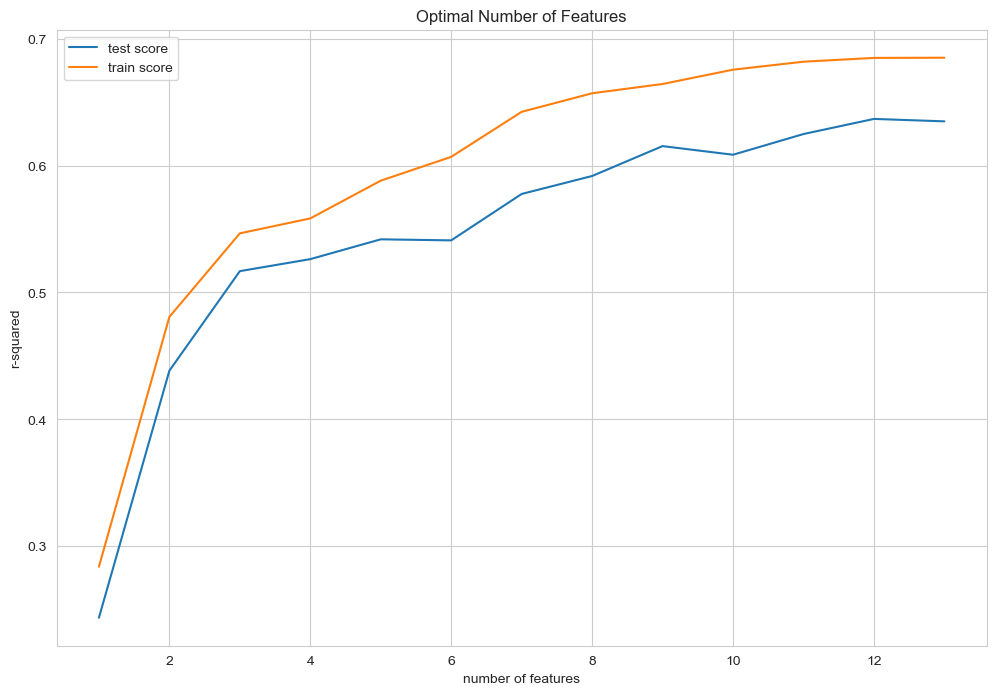

In [52]:
# plotting cv results
plt.figure(figsize=(16, 6))
plt.figure(figsize=(12, 8))
plt.plot(cv_results["param_n_features_to_select"], cv_results["mean_test_score"])
plt.plot(cv_results["param_n_features_to_select"], cv_results["mean_train_score"])
plt.xlabel("number of features")
plt.ylabel("r-squared")
plt.title("Optimal Number of Features")
plt.legend(["test score", "train score"], loc="upper left")
plt.show()

In [44]:
# final model # first time we are seeing the test set
n_features_optimal = 10

lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=n_features_optimal)
rfe = rfe.fit(X_train, y_train)

# predict prices of X_test
y_pred = lm.predict(X_test)
r2 = sklearn.metrics.r2_score(y_test, y_pred)
print(r2)

0.6729582743459918


In [51]:
X_train.columns[rfe.support_]

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'hotwaterheating', 'airconditioning', 'parking', 'prefarea'],
      dtype='object')

In [45]:
X_train[X_train.columns[rfe.support_]].head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,hotwaterheating,airconditioning,parking,prefarea
359,0.155227,0.4,0.0,0.000000,1,0,0,0,0.333333,0
19,0.403379,0.4,0.5,0.333333,1,0,0,1,0.333333,1
159,0.115628,0.4,0.5,0.000000,1,1,0,1,0.000000,0
35,0.454417,0.4,0.5,1.000000,1,0,0,1,0.666667,0
28,0.538015,0.8,0.5,0.333333,1,0,1,0,0.666667,0


In [46]:
y_pred

array([0.20724668, 0.42521187, 0.34390078, 0.30965517, 0.26679159,
       0.20081042, 0.54605698, 0.34459482, 0.15132084, 0.33824567,
       0.10885184, 0.38778083, 0.24973636, 0.48168266, 0.34081042,
       0.4416681 , 0.55569757, 0.22883672, 0.37058649, 0.27048717,
       0.21622618, 0.08541382, 0.23984756, 0.16672718, 0.08343775,
       0.143553  , 0.29819593, 0.41218154, 0.4093423 , 0.28367798,
       0.12030014, 0.24278338, 0.10898889, 0.08625354, 0.27681818,
       0.24897191, 0.24859295, 0.13302812, 0.13846168, 0.21930575,
       0.11751055, 0.36890977, 0.37424519, 0.10598081, 0.07806882,
       0.2499371 , 0.23687591, 0.28967078, 0.13575259, 0.37284403,
       0.02055195, 0.41082617, 0.36076046, 0.41261061, 0.44744552,
       0.28150131, 0.38291105, 0.09432758, 0.08317673, 0.20920304,
       0.091526  , 0.1740686 , 0.47482841, 0.45060196, 0.09529591,
       0.12311174, 0.43519528, 0.08439063, 0.06164695, 0.39596137,
       0.07803973, 0.40667874, 0.19440104, 0.14728027, 0.28964

## car training set

In [53]:
cars = pd.read_csv("CarPrice_Assignment.csv")

In [54]:
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [55]:
len(cars.columns)

26

In [56]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [57]:
cars["symboling"] = cars["symboling"].astype("object")

In [58]:
p = re.compile(r"\w+-?\w+")

In [62]:
cars["car_company"] = cars["CarName"].apply(lambda x: re.findall(p, x)[0])

In [63]:
cars["car_company"].value_counts()

car_company
toyota         31
nissan         17
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
volkswagen      9
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
chevrolet       3
jaguar          3
vw              2
maxda           2
renault         2
toyouta         1
vokswagen       1
Nissan          1
mercury         1
porcshce        1
Name: count, dtype: int64

In [64]:
# Replacing misspelled car_company names
# volkswagen
cars.loc[
    (cars["car_company"] == "vw") | (cars["car_company"] == "vokswagen"), "car_company"
] = "volkswagen"
# porsche
cars.loc[cars["car_company"] == "porcshce", "car_company"] = "porsche"
# toyota
cars.loc[cars["car_company"] == "toyouta", "car_company"] = "toyota"
# nissan
cars.loc[cars["car_company"] == "Nissan", "car_company"] = "nissan"
# mazda
cars.loc[cars["car_company"] == "maxda", "car_company"] = "mazda"

In [65]:
cars["car_company"].value_counts()

car_company
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
volkswagen     12
subaru         12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
jaguar          3
chevrolet       3
alfa-romero     3
renault         2
mercury         1
Name: count, dtype: int64

In [66]:
cars = cars.drop("CarName", axis=1)

# split into X and y
X = cars.loc[
    :,
    [
        "symboling",
        "fueltype",
        "aspiration",
        "doornumber",
        "carbody",
        "drivewheel",
        "enginelocation",
        "wheelbase",
        "carlength",
        "carwidth",
        "carheight",
        "curbweight",
        "enginetype",
        "cylindernumber",
        "enginesize",
        "fuelsystem",
        "boreratio",
        "stroke",
        "compressionratio",
        "horsepower",
        "peakrpm",
        "citympg",
        "highwaympg",
        "car_company",
    ],
]
y = cars["price"]
cars_categorical = X.select_dtypes(include=["object"])
cars_categorical.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem,car_company
0,3,gas,std,two,convertible,rwd,front,dohc,four,mpfi,alfa-romero
1,3,gas,std,two,convertible,rwd,front,dohc,four,mpfi,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi,alfa-romero
3,2,gas,std,four,sedan,fwd,front,ohc,four,mpfi,audi
4,2,gas,std,four,sedan,4wd,front,ohc,five,mpfi,audi


In [67]:
cars_dummies = pd.get_dummies(cars_categorical, drop_first=True)
cars_dummies.head()

,symboling_-1,symboling_0,symboling_1,symboling_2,symboling_3,fueltype_gas,aspiration_turbo,doornumber_two,carbody_hardtop,carbody_hatchback,...,car_company_nissan,car_company_peugeot,car_company_plymouth,car_company_porsche,car_company_renault,car_company_saab,car_company_subaru,car_company_toyota,car_company_volkswagen,car_company_volvo
0,False,False,False,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [68]:
# drop categorical variables
X = X.drop(list(cars_categorical.columns), axis=1)

X = pd.concat([X, cars_dummies], axis=1)

In [69]:
X

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,...,car_company_nissan,car_company_peugeot,car_company_plymouth,car_company_porsche,car_company_renault,car_company_saab,car_company_subaru,car_company_toyota,car_company_volkswagen,car_company_volvo
0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,...,False,False,False,False,False,False,False,False,False,False
1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,...,False,False,False,False,False,False,False,False,False,False
2,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,...,False,False,False,False,False,False,False,False,False,False
3,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,...,False,False,False,False,False,False,False,False,False,False
4,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,...,False,False,False,False,False,False,False,False,False,True
201,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,...,False,False,False,False,False,False,False,False,False,True
202,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,...,False,False,False,False,False,False,False,False,False,True
203,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,...,False,False,False,False,False,False,False,False,False,True


In [70]:
cols = X.columns
X = pd.DataFrame(scale(X))
X

,0,1,2,3,4,5,6,7,8,9,...,58,59,60,61,62,63,64,65,66,67
0,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,0.174483,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
1,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,0.174483,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
2,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,0.604046,-2.404880,0.685946,-0.288349,1.264536,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
3,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.431076,-0.517266,0.462183,-0.035973,-0.053668,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
4,0.107110,0.207256,0.230001,0.235942,0.516807,0.218885,-0.517266,0.462183,-0.540725,0.275883,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.721873,1.198549,1.398245,0.728239,0.763241,0.339248,1.666445,-0.336970,-0.162161,0.250533,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,4.199567
201,1.721873,1.198549,1.351515,0.728239,0.949992,0.339248,1.666445,-0.336970,-0.364062,1.416637,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,4.199567
202,1.721873,1.198549,1.398245,0.728239,0.878757,1.109571,0.926204,-1.232021,-0.338824,0.757535,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,4.199567
203,1.721873,1.198549,1.398245,0.728239,1.273437,0.435538,-1.183483,0.462183,3.244916,0.047732,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,4.199567


In [71]:
X.columns = cols

In [72]:
X

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,...,car_company_nissan,car_company_peugeot,car_company_plymouth,car_company_porsche,car_company_renault,car_company_saab,car_company_subaru,car_company_toyota,car_company_volkswagen,car_company_volvo
0,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,0.174483,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
1,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,0.174483,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
2,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,0.604046,-2.404880,0.685946,-0.288349,1.264536,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
3,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.431076,-0.517266,0.462183,-0.035973,-0.053668,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
4,0.107110,0.207256,0.230001,0.235942,0.516807,0.218885,-0.517266,0.462183,-0.540725,0.275883,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,-0.238120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.721873,1.198549,1.398245,0.728239,0.763241,0.339248,1.666445,-0.336970,-0.162161,0.250533,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,4.199567
201,1.721873,1.198549,1.351515,0.728239,0.949992,0.339248,1.666445,-0.336970,-0.364062,1.416637,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,4.199567
202,1.721873,1.198549,1.398245,0.728239,0.878757,1.109571,0.926204,-1.232021,-0.338824,0.757535,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,4.199567
203,1.721873,1.198549,1.398245,0.728239,1.273437,0.435538,-1.183483,0.462183,3.244916,0.047732,...,-0.310253,-0.23812,-0.188025,-0.158114,-0.099258,-0.17364,-0.249351,-0.430083,-0.249351,4.199567


In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=40
)

In [74]:
len(X_train.columns)

68

## No point of manual feature elimination also

In [75]:
# creating a KFold object with 5 splits
folds = KFold(n_splits=5, shuffle=True, random_state=100)

# specify range of hyperparameters
hyper_params = [{"n_features_to_select": list(range(2, 40))}]

# specify model
lm = LinearRegression()
lm.fit(X_train, y_train)
rfe = RFE(lm)

# set up GridSearchCV()
model_cv = GridSearchCV(
    estimator=rfe,
    param_grid=hyper_params,
    scoring="r2",
    cv=folds,
    verbose=1,
    return_train_score=True,
)

# fit the model
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 38 candidates, totalling 190 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=100, shuffle=True),
             estimator=RFE(estimator=LinearRegression()),
             param_grid=[{'n_features_to_select': [2, 3, 4, 5, 6, 7, 8, 9, 10,
                                                   11, 12, 13, 14, 15, 16, 17,
                                                   18, 19, 20, 21, 22, 23, 24,
                                                   25, 26, 27, 28, 29, 30, 31, ...]}],
             return_train_score=True, scoring='r2', verbose=1)

In [76]:
40 * 0.9688

38.752

In [80]:
lis = [1, 2, 3, 4, 5, 6, 7, 8]
k = 3
out = []
n = len(lis)
i = 0
while i < n:
    print(lis[i : i + k])
    i += k

[1, 2, 3]
[4, 5, 6]
[7, 8]
